In [1]:
import pandas as pd
import numpy as np
import warnings
from pathlib import Path
import sys
import os
from datetime import datetime

project_root = Path.cwd()
while not (project_root / "src").exists():
    project_root = project_root.parent
project_root_str = str(project_root)

if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

os.chdir(project_root_str)

from src.utils.team_info import *
from src.historical_analysis.dataScraper import *

warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)

In [5]:
import joblib

project_root = Path("/Users/alexgonzalez/Documents/NBA-Prop-Predictor")  # or Path.cwd()
min_path = project_root / "src/models/saved_models/min_quantile_xgb_2026-02-02.joblib"
ppm_path = project_root / "src/models/saved_models/ppm_quantile_xgb_2026-02-03.joblib"

min_bundle = joblib.load(min_path)
min_models = min_bundle["quantile_models"]
min_feature_names = min_bundle["feature_names"]

ppm_bundle = joblib.load(ppm_path)
ppm_models = ppm_bundle["quantile_models"]
ppm_feature_names = ppm_bundle["feature_names"]


#load season stats
pts_df = pd.read_csv('data/processed/training/S26_TRAINING_PPM.csv')
ast_df = pd.read_csv('data/processed/training/S26_TRAINING_APM.csv')
reb_df = pd.read_csv('data/processed/training/S26_TRAINING_RPM.csv')
min_df = pd.read_csv('data/processed/training/S26_TRAINING_MIN.csv')

### Solo lookup

In [6]:
def grab_player_last_game(df, features, player, date):
    pdf = df[(df['PLAYER_NAME'] == player) & (df['GAME_DATE'] == date)]
    if pdf.empty:
        return f"No data found for {player} on {date}"
    return pdf[features]
player = 'Luke Kornet'
last_mins = grab_player_last_game(min_df, min_feature_names, player, '2026-04-06')
last_ppm = grab_player_last_game(pts_df, ppm_feature_names, player, '2026-04-06')

min_arr = np.asarray(last_mins, dtype=float).reshape(1, -1)
ppm_arr = np.asarray(last_ppm, dtype=float).reshape(1, -1)

min_pred = min_models['q_0.50'].predict(min_arr)
ppm_pred = ppm_models['q_0.50'].predict(ppm_arr)
print(f"predicted MIN: {min_pred[0]:.2f}, predicted PPM: {ppm_pred[0]:.2f}, predicted PTS: {min_pred[0] * ppm_pred[0]:.2f}")
last_mins

predicted MIN: 17.35, predicted PPM: 0.26, predicted PTS: 4.43


,GP,POSITION_ENC,STARTER_X_MIN_AVG,STARTING_lag1,STARTER_ROLL10_PCT,IS_TOP_STAR,IS_SECOND_STAR,IS_THIRD_STAR,MAIN_STAR_MINUTES_PLAYED,SECONDARY_STAR_MINUTES_PLAYED,THIRD_STAR_MINUTES_PLAYED,TOTAL_STAR_MINUTES,mins_all_stars_out,TEAM_MIN_RANK_L10,MIN_EWM_L10,MIN_lag1,ROLE_LOCK,TEAM_USG_RANK_L10,MIN_ROLE_Z_SCORE,POSS_season_avg,MIN_MAX_L10,MIN_MIN_L10,SEASON_STD
84456,65,0,0.0,0.0,0.2,0,0,0,15.661667,26.533333,30.638333,72.833333,NaN,9.0,18.74655,13.398333,0.055096,9.0,-0.188084,44.78,25.071667,13.398333,5.770461


### Week lookup 

In [19]:
date = '2026-03-08'

backtest_df = pd.read_csv(f'/Users/alexgonzalez/Documents/NBA-Prop-Predictor/data/backtest/historical_odds/{date}.csv')
backtest_df = backtest_df[backtest_df['prop'] == 'Points']

res = []

for player in backtest_df['player']:
    pdf = pts_df[(pts_df['PLAYER_NAME'] == player) & (pts_df['GAME_DATE'] == date)]
    if pdf.empty:
        print(f"No data found for {player} on {date}")
        continue
    last_mins = grab_player_last_game(min_df, min_feature_names, player, date)
    last_ppm = grab_player_last_game(pts_df, ppm_feature_names, player, date)
    if not isinstance(last_mins, pd.DataFrame) or not isinstance(last_ppm, pd.DataFrame):
        continue
    line = backtest_df[backtest_df['player'] == player]['line'].values[0]
    actual_pts = pts_df[(pts_df['PLAYER_NAME'] == player) & (pts_df['GAME_DATE'] == date)]['PTS'].values[0]
    actual_min = pts_df[(pts_df['PLAYER_NAME'] == player) & (pts_df['GAME_DATE'] == date)]['MIN'].values[0]

    min_arr = np.asarray(last_mins, dtype=float).reshape(1, -1)
    ppm_arr = np.asarray(last_ppm, dtype=float).reshape(1, -1)
    min_pred = min_models['q_0.50'].predict(min_arr)
    ppm_pred = ppm_models['q_0.50'].predict(ppm_arr)
    pred = float(min_pred[0] * ppm_pred[0])
    side = 'Over' if pred > line else 'Under'
    hit = (side == "Over" and actual_pts > line) or (side == "Under" and actual_pts < line)
    res.append({
        'player': player,
        'pred points': pred,
        'side': side,
        'line': line,
        'actual points': actual_pts,
        'error': abs(pred - actual_pts),
        'hit': int(hit)
    })
res = pd.DataFrame(res)
res.sort_values(by='error', ascending=False).head(20)

No data found for Vit Krejci on 2026-03-08
No data found for DeMar DeRozan on 2026-03-08
No data found for Bobby Portis Jr. on 2026-03-08
No data found for LeBron James on 2026-03-08
No data found for Grayson Allen on 2026-03-08
No data found for Giannis Antetokounmpo on 2026-03-08
No data found for P.J. Washington Jr. on 2026-03-08
No data found for Moussa Diabate on 2026-03-08
No data found for Hugo Gonzalez on 2026-03-08
No data found for Dennis Schroder on 2026-03-08


,player,pred points,side,line,actual points,error,hit
75,Scoot Henderson,10.941961,Under,11.5,28,17.058039,0
32,Mikal Bridges,15.663201,Over,14.5,0,15.663201,0
42,Maxime Raynaud,11.212896,Under,15.5,26,14.787104,0
21,Derrick White,16.983305,Over,15.5,6,10.983305,0
27,Collin Gillespie,13.325255,Over,12.5,24,10.674745,1
23,Keldon Johnson,10.350763,Under,10.5,20,9.649237,0
88,Max Christie,11.152546,Under,11.5,2,9.152546,1
83,Tari Eason,10.478653,Under,10.5,2,8.478653,1
20,Dylan Harper,10.524574,Over,9.5,19,8.475426,1
65,Evan Mobley,16.090855,Under,16.5,24,7.909145,0


In [21]:
def summarize(res, juice=-110):
    """Headline metrics over a `res` frame produced by the backtest loop."""
    n = len(res)
    if n == 0:
        return pd.Series({"n": 0})
    hits = int(res["hit"].sum())
    err = (res["pred points"] - res["actual points"]).astype(float)

    risk = abs(juice) / 100 if juice < 0 else 1.0
    payout = 1.0 if juice < 0 else juice / 100
    profit = res["hit"].map({1: payout, 0: -risk}).sum()
    roi = profit / (n * risk) * 100

    return pd.Series({
        "n_bets": n,
        "hits": hits,
        "hit_rate_%": round(hits / n * 100, 2),
        "MAE_pts": round(err.abs().mean(), 2),
        "RMSE_pts": round((err ** 2).mean() ** 0.5, 2),
        "ME_pts (bias)": round(err.mean(), 2),
        f"profit_units@{juice}": round(profit, 2),
        f"ROI_%@{juice}": round(roi, 2),
        "break_even_%": round(risk / (risk + payout) * 100, 2),
    })

summarize(res)

n_bets               90.00
hits                 58.00
hit_rate_%           64.44
MAE_pts               3.71
RMSE_pts              5.18
ME_pts (bias)         0.05
profit_units@-110    22.80
ROI_%@-110           23.03
break_even_%         52.38
dtype: float64

### Slice diagnostics
Hit rate / ROI broken down by side, line range, and predicted edge.

In [22]:
def hit_rate_by(df, by, juice=-110):
    risk = abs(juice) / 100 if juice < 0 else 1.0
    payout = 1.0 if juice < 0 else juice / 100
    g = df.groupby(by)
    out = g["hit"].agg(["count", "sum"]).rename(columns={"count": "n", "sum": "hits"})
    out["hit_%"] = (out["hits"] / out["n"] * 100).round(2)
    profit = g["hit"].apply(lambda s: s.map({1: payout, 0: -risk}).sum())
    out[f"profit@{juice}"] = profit.round(2)
    out[f"ROI_%@{juice}"] = (profit / (out["n"] * risk) * 100).round(2)
    return out.sort_values("n", ascending=False)

print("By side:")
display(hit_rate_by(res, "side"))

By side:


,n,hits,hit_%,profit@-110,ROI_%@-110
side,,,,,
Over,47,29,61.70,9.2,17.79
Under,43,29,67.44,13.6,28.75


In [23]:
res_view = res.copy()
res_view["edge"] = (res_view["pred points"] - res_view["line"]).round(2)
res_view["abs_edge"] = res_view["edge"].abs()
res_view["line_bucket"] = pd.cut(
    res_view["line"], bins=[0, 9.5, 14.5, 19.5, 24.5, 100],
    labels=["≤9.5", "10–14", "15–19", "20–24", "25+"],
)
res_view["edge_bucket"] = pd.cut(
    res_view["abs_edge"], bins=[-0.01, 1, 2.5, 5, 10, 1000],
    labels=["<1", "1–2.5", "2.5–5", "5–10", "10+"],
)

print("By line range:")
display(hit_rate_by(res_view, "line_bucket"))

print("\nBy |edge| (model confidence):")
display(hit_rate_by(res_view, "edge_bucket"))

By line range:


,n,hits,hit_%,profit@-110,ROI_%@-110
line_bucket,,,,,
10–14,32,22,68.75,11.0,31.25
≤9.5,26,13,50.00,-1.3,-4.55
15–19,19,10,52.63,0.1,0.48
20–24,8,8,100.00,8.0,90.91
25+,5,5,100.00,5.0,90.91



By |edge| (model confidence):


,n,hits,hit_%,profit@-110,ROI_%@-110
edge_bucket,,,,,
<1,45,28,62.22,9.3,18.79
1–2.5,25,13,52.00,-0.2,-0.73
2.5–5,13,10,76.92,6.7,46.85
5–10,6,6,100.00,6.0,90.91
10+,1,1,100.00,1.0,90.91


### Confidence threshold sweep
Only bet when the model edge is at least `t`. Helps find the cutoff where ROI is positive.

In [24]:
def threshold_sweep(df, thresholds=(0, 1, 1.5, 2, 2.5, 3, 4, 5, 7), juice=-110):
    risk = abs(juice) / 100 if juice < 0 else 1.0
    payout = 1.0 if juice < 0 else juice / 100
    rows = []
    abs_edge = (df["pred points"] - df["line"]).abs()
    for t in thresholds:
        sub = df[abs_edge >= t]
        n = len(sub)
        if n == 0:
            rows.append({"min_edge": t, "n": 0, "hit_%": None, "profit": 0.0, "ROI_%": None})
            continue
        hits = int(sub["hit"].sum())
        profit = sub["hit"].map({1: payout, 0: -risk}).sum()
        rows.append({
            "min_edge": t,
            "n": n,
            "hit_%": round(hits / n * 100, 2),
            "profit": round(profit, 2),
            "ROI_%": round(profit / (n * risk) * 100, 2),
        })
    return pd.DataFrame(rows)

threshold_sweep(res)

,min_edge,n,hit_%,profit,ROI_%
0,0.0,90,64.44,22.8,23.03
1,1.0,45,66.67,13.5,27.27
2,1.5,32,75.00,15.2,43.18
3,2.0,25,80.00,14.5,52.73
4,2.5,20,85.00,13.7,62.27
5,3.0,18,83.33,11.7,59.09
6,4.0,13,92.31,10.9,76.22
7,5.0,7,100.00,7.0,90.91
8,7.0,4,100.00,4.0,90.91


### Calibration & residual plots
Pred vs actual (with y=x line) and residual histogram tell you about systematic bias and spread.

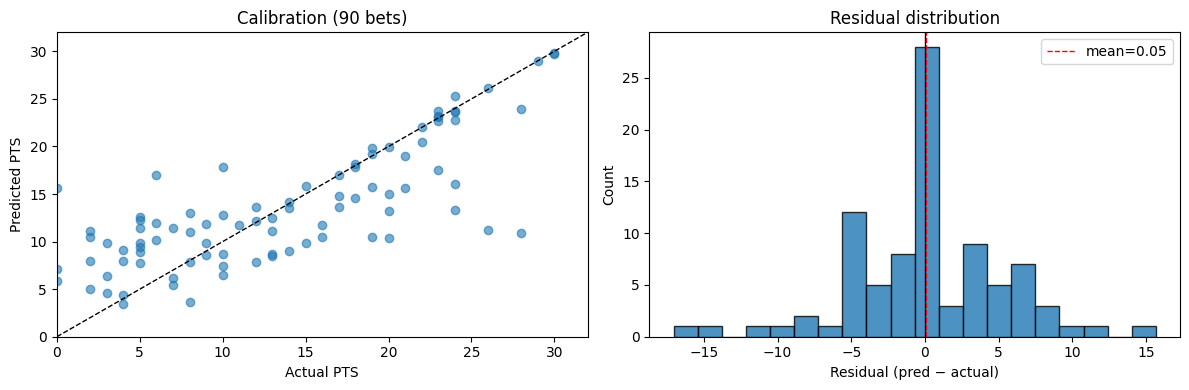

In [25]:
import matplotlib.pyplot as plt

resid = (res["pred points"] - res["actual points"]).astype(float)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
lims = [0, max(res["pred points"].max(), res["actual points"].max()) + 2]
ax.scatter(res["actual points"], res["pred points"], alpha=0.6)
ax.plot(lims, lims, "k--", lw=1)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("Actual PTS")
ax.set_ylabel("Predicted PTS")
ax.set_title(f"Calibration ({len(res)} bets)")

ax = axes[1]
ax.hist(resid, bins=20, edgecolor="black", alpha=0.8)
ax.axvline(0, color="k", lw=1)
ax.axvline(resid.mean(), color="red", lw=1, ls="--", label=f"mean={resid.mean():.2f}")
ax.set_xlabel("Residual (pred − actual)")
ax.set_ylabel("Count")
ax.set_title("Residual distribution")
ax.legend()

plt.tight_layout(); plt.show()

### Best & worst bets
Top hits with biggest edge (model wins big) and worst misses (model lost big).

In [26]:
tmp = res.copy()
tmp["edge"] = (tmp["pred points"] - tmp["line"]).round(2)
tmp["miss"] = (tmp["pred points"] - tmp["actual points"]).round(2)

print("Biggest edge HITS (model right + confident):")
display(
    tmp[tmp["hit"] == 1]
    .reindex(tmp[tmp["hit"] == 1]["edge"].abs().sort_values(ascending=False).index)
    .head(10)
)

print("\nBiggest edge MISSES (model wrong + confident):")
display(
    tmp[tmp["hit"] == 0]
    .reindex(tmp[tmp["hit"] == 0]["edge"].abs().sort_values(ascending=False).index)
    .head(10)
)

Biggest edge HITS (model right + confident):


,player,pred points,side,line,actual points,error,hit,edge,miss
3,Collin Sexton,23.899870,Over,12.5,28,4.100130,1,11.40,-4.10
35,Brandon Ingram,11.701200,Under,21.5,11,0.701200,1,-9.80,0.70
76,Jalen Duren,25.305914,Over,17.5,24,1.305914,1,7.81,1.31
78,Stephon Castle,23.073126,Over,15.5,23,0.073126,1,7.57,0.07
84,Amen Thompson,22.720720,Over,16.5,23,0.279280,1,6.22,-0.28
4,Neemias Queta,3.409517,Under,9.5,4,0.590483,1,-6.09,-0.59
51,Mitchell Robinson,4.387701,Under,9.5,4,0.387701,1,-5.11,0.39
8,Victor Wembanyama,28.962360,Over,24.5,29,0.037640,1,4.46,-0.04
72,Devin Booker,29.849262,Over,25.5,30,0.150738,1,4.35,-0.15
18,Donovan Mitchell,29.700390,Over,25.5,30,0.299610,1,4.20,-0.30



Biggest edge MISSES (model wrong + confident):


,player,pred points,side,line,actual points,error,hit,edge,miss
42,Maxime Raynaud,11.212896,Under,15.5,26,14.787104,0,-4.29,-14.79
28,Jrue Holiday,15.677355,Under,19.5,21,5.322645,0,-3.82,-5.32
5,Matas Buzelis,15.029491,Under,18.5,20,4.970509,0,-3.47,-4.97
26,Jaden Hardy,7.415272,Under,9.5,10,2.584728,0,-2.08,-2.58
6,Saddiq Bey,17.494524,Under,19.5,23,5.505476,0,-2.01,-5.51
31,Sam Merrill,12.302809,Over,10.5,5,7.302809,0,1.80,7.30
24,Luke Kennard,7.859682,Under,9.5,12,4.140318,0,-1.64,-4.14
59,Josh Hart,13.024799,Over,11.5,8,5.024799,0,1.52,5.02
21,Derrick White,16.983305,Over,15.5,6,10.983305,0,1.48,10.98
82,Khris Middleton,11.961285,Over,10.5,6,5.961285,0,1.46,5.96
